In [13]:
import os
import sys
from datetime import datetime
import itertools

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

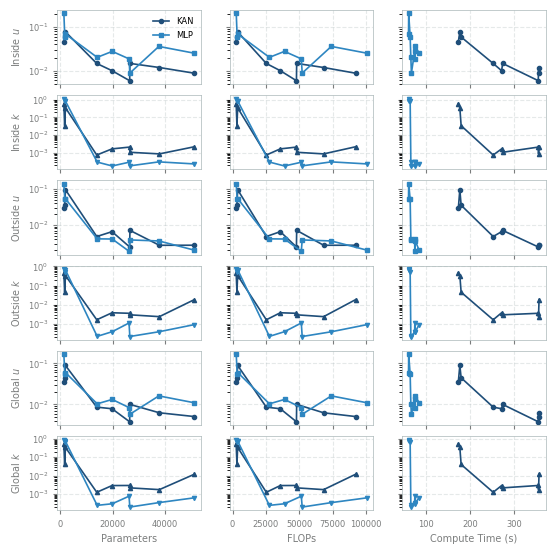

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Custom Aesthetic Palette
# =========================================================
palette = {
    "kan": "#1f4e79",          # Deep professional blue for KAN
    "mlp": "#2e86c1",          # Lighter complementary blue for MLP
    "pde": "#7fb3d5",          # Accent tone
    "text_muted": "#7b7d7d",   # Muted color for labels/ticks
    "spine": "#aab7b8",        # Subtle color for axis spines
}

# =========================================================
# Load Data & Clean Headers
# =========================================================
results_dir = "results_accuracy_efficiency_4"
csv_path = os.path.join(results_dir, "summary_metrics.csv")
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# =========================================================
# Plotting (6x3 Panel Layout: Separating u and k across regions)
# =========================================================
fig, axes = plt.subplots(
    6, 3,
    figsize=(6.3, 6.5),
    sharex='col',
    sharey='row'
)

# Helper function to plot a single error metric trend line
def plot_single_trend(ax, df_kan, df_mlp, x_col, region, var_type):
    kan_sorted = df_kan.sort_values(x_col)
    mlp_sorted = df_mlp.sort_values(x_col)
    
    col_name = f"err_{var_type}_{region}"
    marker_kan = 'o' if var_type == 'u' else '^'
    marker_mlp = 's' if var_type == 'u' else 'v'
    
    ax.plot(kan_sorted[x_col], kan_sorted[col_name], marker=marker_kan, linestyle='-', color=palette["kan"], lw=1.2, ms=3.0, label="KAN")
    ax.plot(mlp_sorted[x_col], mlp_sorted[col_name], marker=marker_mlp, linestyle='-', color=palette["mlp"], lw=1.2, ms=3.0, label="MLP")
    ax.set_yscale('log')

metrics_x = ["parameters", "flops", "compute_time_sec"]
x_labels = ["Parameters", "FLOPs", "Compute Time (s)"]

# Row configuration: (region, variable_type, display_label)
row_configs = [
    ("inside", "u", "Inside $u$"),
    ("inside", "k", "Inside $k$"),
    ("outside", "u", "Outside $u$"),
    ("outside", "k", "Outside $k$"),
    ("global", "u", "Global $u$"),
    ("global", "k", "Global $k$"),
]

# Loop through columns and rows
for col_idx, x_col in enumerate(metrics_x):
    for row_idx, (region, var_type, _) in enumerate(row_configs):
        plot_single_trend(
            axes[row_idx, col_idx], 
            df[df["model_type"] == "KAN"], 
            df[df["model_type"] == "MLP"], 
            x_col, 
            region, 
            var_type
        )
        
    # Set X labels on the bottom row only (Row 5)
    axes[5, col_idx].set_xlabel(x_labels[col_idx], fontsize=7, color=palette["text_muted"])

# Set Y labels for each row
for row_idx, (_, _, label_text) in enumerate(row_configs):
    axes[row_idx, 0].set_ylabel(label_text, fontsize=7, color=palette["text_muted"])

# Add legend to the top-left panel to avoid clutter
axes[0, 0].legend(frameon=False, fontsize=6, loc="upper right")

# =========================================================
# Customizing Panel 3 (Compute Time) to Linear Scale
# =========================================================
for row in range(6):
    axes[row, 2].set_xscale('linear')

# =========================================================
# Styling & Palette Formatting
# =========================================================
for row in axes:
    for ax in row:
        ax.tick_params(axis="both", labelsize=6, colors=palette["text_muted"])
        ax.grid(True, linestyle='--', alpha=0.3, color=palette["spine"])
        
        for spine in ax.spines.values():
            spine.set_color(palette["spine"])
            spine.set_linewidth(0.5)

# Tighter vertical spacing to reduce overall plot height
plt.subplots_adjust(wspace=0.2, hspace=0.15)

os.makedirs("figures", exist_ok=True)
fig_path = "figures/tradeoff.pdf"
plt.savefig(fig_path, bbox_inches="tight", dpi=300)
plt.show()

